# Laboratorio visual: ¿cómo busca una IA la mejor decisión?

**Fundamentos de Inteligencia Artificial · Clase 3 · Restricciones y optimización**  
**Dra. Alejandra Hernández Sánchez**

Este notebook muestra, sobre el mismo problema de la presentación, cómo trabajan:

1. búsqueda exhaustiva;
2. backtracking;
3. backtracking con propagación y cota;
4. hill climbing;
5. recocido simulado.

La intención no es solamente obtener la respuesta. Aquí vamos a **ver qué soluciones visita cada método, cuánto trabajo realiza, cuándo se atora y cómo cambian sus resultados al mover parámetros**.

> Ejecuta las celdas en orden. Las que dicen **LABORATORIO** tienen controles o parámetros para experimentar.


## 0. Preparación

El notebook utiliza únicamente bibliotecas disponibles normalmente en Google Colab. No requiere OR-Tools porque aquí programamos funciones pequeñas para observar el comportamiento interno de los métodos.


In [22]:
import itertools
import math
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 4.8)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

COLORES = {"A": "#2563EB", "B": "#7C3AED", "C": "#F59E0B"}
VERDE = "#16A34A"
ROJO = "#DC2626"
GRIS = "#64748B"

print("✓ Entorno preparado")


✓ Entorno preparado


## 1. El problema de la presentación

Hay que repartir seis pedidos entre tres repartidores. Cada número indica los minutos que tarda una persona en realizar un pedido.

### Restricciones duras

- Ningún repartidor puede recibir más de 3 pedidos.
- P1 y P2 no pueden asignarse al mismo repartidor.
- P3 solamente puede asignarse a A o B.
- P6 no puede asignarse a C.

### Objetivo

Minimizar la suma de los minutos de los seis pedidos.


In [23]:
PEDIDOS = ["P1", "P2", "P3", "P4", "P5", "P6"]
REPARTIDORES = ["A", "B", "C"]

COSTOS = pd.DataFrame(
    [
        [7,  4, 10],
        [6,  9, 13],
        [13, 9,  5],
        [8,  7, 13],
        [12, 13, 8],
        [9, 14, 12],
    ],
    index=PEDIDOS,
    columns=REPARTIDORES,
)

display(COSTOS.style.background_gradient(cmap="YlOrRd", axis=None).format("{} min"))


,A,B,C
P1,7 min,4 min,10 min
P2,6 min,9 min,13 min
P3,13 min,9 min,5 min
P4,8 min,7 min,13 min
P5,12 min,13 min,8 min
P6,9 min,14 min,12 min


In [24]:
def normalizar(solucion):
    # Convierte 'BABBCA', listas o tuplas a una tupla comparable.
    if isinstance(solucion, str):
        solucion = list(solucion.replace("-", "").replace(" ", ""))
    solucion = tuple(solucion)
    if len(solucion) != len(PEDIDOS):
        raise ValueError("La solución debe contener una asignación para cada pedido.")
    if any(r not in REPARTIDORES for r in solucion):
        raise ValueError("Cada asignación debe ser A, B o C.")
    return solucion


def costo(solucion):
    # Calcula los minutos totales de una asignación completa.
    solucion = normalizar(solucion)
    return int(sum(COSTOS.loc[p, r] for p, r in zip(PEDIDOS, solucion)))


def diagnosticar(solucion, capacidad=3):
    # Devuelve las restricciones duras que rompe una solución completa.
    s = normalizar(solucion)
    razones = []
    for r in REPARTIDORES:
        if s.count(r) > capacidad:
            razones.append(f"{r} supera la capacidad de {capacidad} pedidos")
    if s[0] == s[1]:
        razones.append("P1 y P2 quedaron con el mismo repartidor")
    if s[2] == "C":
        razones.append("P3 requiere certificación y no puede ir con C")
    if s[5] == "C":
        razones.append("P6 requiere refrigeración y no puede ir con C")
    return razones


def es_factible(solucion, capacidad=3):
    return len(diagnosticar(solucion, capacidad)) == 0


def tabla_solucion(solucion):
    s = normalizar(solucion)
    return pd.DataFrame({
        "Pedido": PEDIDOS,
        "Repartidor": s,
        "Minutos": [int(COSTOS.loc[p, r]) for p, r in zip(PEDIDOS, s)],
    })


def mostrar_solucion(solucion, titulo="Solución", capacidad=3):
    s = normalizar(solucion)
    razones = diagnosticar(s, capacidad)
    estado = "FACTIBLE" if not razones else "NO FACTIBLE"
    color = VERDE if not razones else ROJO
    print(f"{titulo}: {''.join(s)} | costo = {costo(s)} min | {estado}")
    if razones:
        for razon in razones:
            print("  •", razon)
    estilos = [f"background-color: {COLORES[r]}22; color: #111827" for r in s]
    display(tabla_solucion(s).style.apply(lambda _: estilos, subset=["Repartidor"]))


mostrar_solucion("BABBCA", "Solución mostrada en la presentación")


Solución mostrada en la presentación: BABBCA | costo = 43 min | FACTIBLE


,Pedido,Repartidor,Minutos
0,P1,B,4
1,P2,A,6
2,P3,B,9
3,P4,B,7
4,P5,C,8
5,P6,A,9


## 2. Antes de optimizar: visualizar todo el espacio

Con seis pedidos y tres opciones hay $3^6=729$ asignaciones posibles. Las restricciones reducen ese conjunto a 156 soluciones factibles.

La primera gráfica muestra qué porcentaje del espacio sobrevive a las reglas. La segunda muestra la distribución de costos de las soluciones factibles.


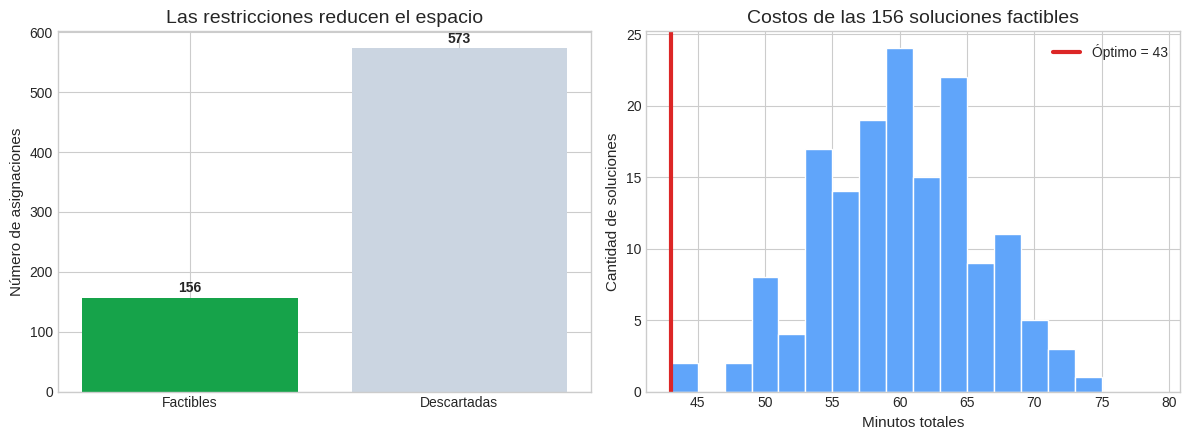

Posibles: 729 | Factibles: 156 | Mejor costo: 43


,solucion,costo,factible
0,BABBCA,43,True
1,BABACA,44,True
2,BABBAA,47,True
3,BAABCA,47,True
4,BABCCA,49,True
5,BABACB,49,True
6,ABBBCA,49,True
7,BABABA,49,True


In [25]:
def construir_espacio(capacidad=3):
    filas = []
    for s in itertools.product(REPARTIDORES, repeat=len(PEDIDOS)):
        filas.append({
            "solucion": "".join(s),
            "costo": costo(s),
            "factible": es_factible(s, capacidad),
        })
    return pd.DataFrame(filas)


ESPACIO = construir_espacio()
FACTIBLES = ESPACIO[ESPACIO["factible"]].copy().sort_values("costo")
OPTIMO = int(FACTIBLES["costo"].min())

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

conteos = ESPACIO["factible"].value_counts().reindex([True, False])
ax[0].bar(["Factibles", "Descartadas"], conteos.values, color=[VERDE, "#CBD5E1"])
for i, v in enumerate(conteos.values):
    ax[0].text(i, v + 10, str(v), ha="center", fontweight="bold")
ax[0].set_title("Las restricciones reducen el espacio")
ax[0].set_ylabel("Número de asignaciones")

ax[1].hist(FACTIBLES["costo"], bins=range(43, 80, 2), color="#60A5FA", edgecolor="white")
ax[1].axvline(OPTIMO, color=ROJO, linewidth=3, label=f"Óptimo = {OPTIMO}")
ax[1].set_title("Costos de las 156 soluciones factibles")
ax[1].set_xlabel("Minutos totales")
ax[1].set_ylabel("Cantidad de soluciones")
ax[1].legend()

plt.tight_layout()
plt.show()

print(f"Posibles: {len(ESPACIO)} | Factibles: {len(FACTIBLES)} | Mejor costo: {OPTIMO}")
display(FACTIBLES.head(8).reset_index(drop=True))


## 3. Búsqueda exhaustiva: mirar absolutamente todo

La búsqueda exhaustiva genera las 729 asignaciones, descarta las ilegales y conserva la mejor. Garantiza el óptimo, pero su trabajo crece exponencialmente.


Resultado exhaustivo: BABBCA | costo = 43 min | FACTIBLE


,Pedido,Repartidor,Minutos
0,P1,B,4
1,P2,A,6
2,P3,B,9
3,P4,B,7
4,P5,C,8
5,P6,A,9


Revisó 729 asignaciones; 156 eran legales.


,evaluacion,solucion,costo
0,86,ABAABB,64
1,89,ABAACB,59
2,94,ABABBA,58
3,97,ABABCA,53
4,115,ABBACA,50
5,124,ABBBCA,49
6,259,BAABCA,47
7,277,BABACA,44
8,286,BABBCA,43


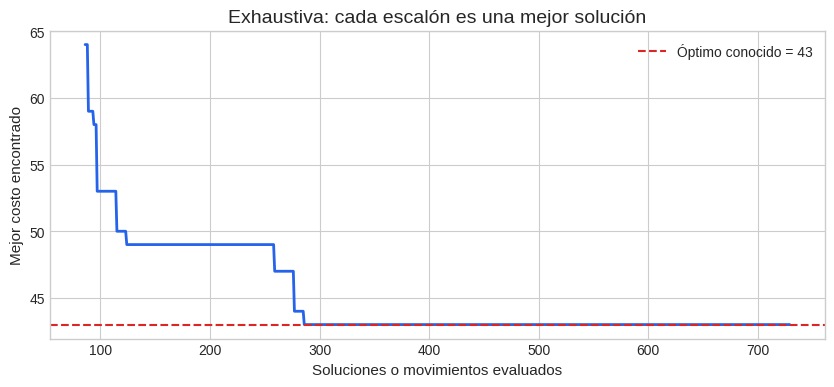

In [26]:
def busqueda_exhaustiva(capacidad=3):
    mejor = None
    mejor_costo = math.inf
    mejoras = []
    traza_x, traza_mejor = [], []
    factibles = 0

    for evaluadas, s in enumerate(itertools.product(REPARTIDORES, repeat=len(PEDIDOS)), start=1):
        if es_factible(s, capacidad):
            factibles += 1
            c = costo(s)
            if c < mejor_costo:
                mejor, mejor_costo = s, c
                mejoras.append({"evaluacion": evaluadas, "solucion": "".join(s), "costo": c})
        traza_x.append(evaluadas)
        traza_mejor.append(mejor_costo if mejor is not None else np.nan)

    return {
        "metodo": "Búsqueda exhaustiva",
        "solucion": mejor,
        "costo": mejor_costo,
        "evaluadas": evaluadas,
        "factibles": factibles,
        "mejoras": pd.DataFrame(mejoras),
        "traza_x": traza_x,
        "traza_mejor": traza_mejor,
        "garantiza": True,
    }


def graficar_convergencia(resultado, titulo=None):
    plt.figure(figsize=(10, 4))
    plt.plot(resultado["traza_x"], resultado["traza_mejor"], color="#2563EB", linewidth=2)
    plt.axhline(OPTIMO, color=ROJO, linestyle="--", label=f"Óptimo conocido = {OPTIMO}")
    plt.xlabel("Soluciones o movimientos evaluados")
    plt.ylabel("Mejor costo encontrado")
    plt.title(titulo or resultado["metodo"])
    plt.legend()
    plt.show()


R_EXH = busqueda_exhaustiva()
mostrar_solucion(R_EXH["solucion"], "Resultado exhaustivo")
print(f"Revisó {R_EXH['evaluadas']} asignaciones; {R_EXH['factibles']} eran legales.")
display(R_EXH["mejoras"])
graficar_convergencia(R_EXH, "Exhaustiva: cada escalón es una mejor solución")


## 4. Backtracking: dejar de explorar una rama cuando ya no sirve

Backtracking asigna los pedidos uno por uno. Si una asignación parcial rompe una regla o ya cuesta más que la mejor solución conocida, regresa inmediatamente.

Con **propagación y cota**, además calcula el costo mínimo que todavía falta pagar. Si incluso en el mejor escenario esa rama no puede mejorar la respuesta, la poda antes.


,Método,Intentos,Costo,intentos,poda_reglas,poda_costo,poda_cota,hojas
0,Backtracking,264,43,264,66,102,0,9
1,Backtracking + propagación,75,43,75,21,4,17,9


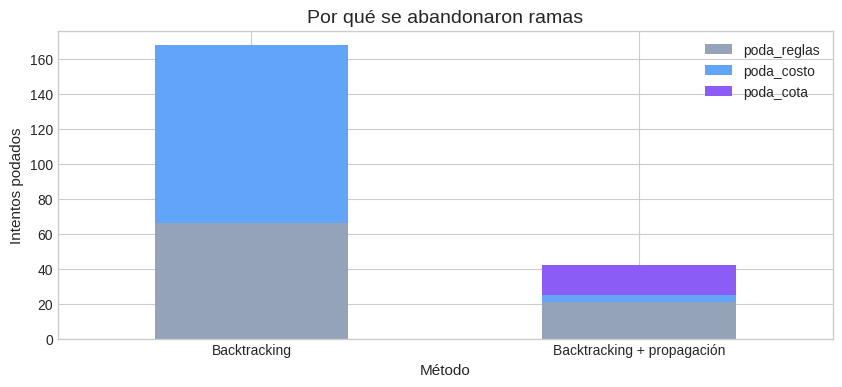

Cifras esperadas con el orden ABC: 264 intentos sin cota y 75 con propagación/cota.


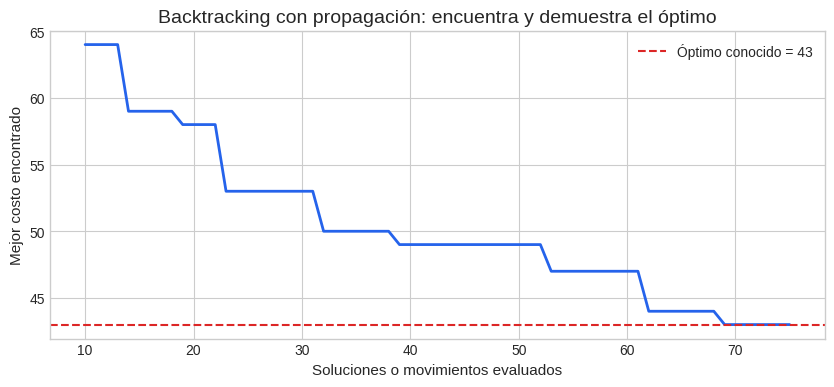

In [27]:
def parcial_factible(parcial, capacidad=3):
    if any(parcial.count(r) > capacidad for r in REPARTIDORES):
        return False
    if len(parcial) >= 2 and parcial[0] == parcial[1]:
        return False
    if len(parcial) >= 3 and parcial[2] == "C":
        return False
    if len(parcial) >= 6 and parcial[5] == "C":
        return False
    return True


def opciones_admisibles(indice, parcial, capacidad=3):
    opciones = []
    for r in REPARTIDORES:
        if indice in (2, 5) and r == "C":
            continue
        if indice == 1 and len(parcial) >= 1 and r == parcial[0]:
            continue
        if parcial.count(r) >= capacidad:
            continue
        opciones.append(r)
    return opciones


def cota_inferior(indice, parcial, capacidad=3):
    # Mejor costo imaginable para los pedidos que todavía faltan.
    minimo_restante = 0
    for j in range(indice, len(PEDIDOS)):
        opciones = opciones_admisibles(j, parcial, capacidad)
        if not opciones:
            return math.inf
        minimo_restante += min(int(COSTOS.loc[PEDIDOS[j], r]) for r in opciones)
    return minimo_restante


def backtracking(propagacion=False, capacidad=3, orden_valores="ABC"):
    mejor = None
    mejor_costo = math.inf
    stats = {"intentos": 0, "poda_reglas": 0, "poda_costo": 0, "poda_cota": 0, "hojas": 0}
    mejoras = []
    traza_x, traza_mejor = [], []

    def orden_para(indice):
        if orden_valores == "costo":
            return sorted(REPARTIDORES, key=lambda r: COSTOS.loc[PEDIDOS[indice], r])
        return list(REPARTIDORES)

    def explorar(indice, parcial, costo_parcial):
        nonlocal mejor, mejor_costo
        if indice == len(PEDIDOS):
            stats["hojas"] += 1
            if costo_parcial < mejor_costo:
                mejor, mejor_costo = parcial, costo_parcial
                mejoras.append({
                    "intento": stats["intentos"],
                    "solucion": "".join(parcial),
                    "costo": mejor_costo,
                })
            return

        for r in orden_para(indice):
            stats["intentos"] += 1
            nuevo = parcial + (r,)

            if not parcial_factible(nuevo, capacidad):
                stats["poda_reglas"] += 1
                traza_x.append(stats["intentos"])
                traza_mejor.append(mejor_costo if mejor is not None else np.nan)
                continue

            nuevo_costo = costo_parcial + int(COSTOS.loc[PEDIDOS[indice], r])
            if nuevo_costo >= mejor_costo:
                stats["poda_costo"] += 1
                traza_x.append(stats["intentos"])
                traza_mejor.append(mejor_costo)
                continue

            if propagacion:
                limite = nuevo_costo + cota_inferior(indice + 1, nuevo, capacidad)
                if limite >= mejor_costo:
                    stats["poda_cota"] += 1
                    traza_x.append(stats["intentos"])
                    traza_mejor.append(mejor_costo)
                    continue

            traza_x.append(stats["intentos"])
            traza_mejor.append(mejor_costo if mejor is not None else np.nan)
            explorar(indice + 1, nuevo, nuevo_costo)

    explorar(0, tuple(), 0)
    return {
        "metodo": "Backtracking + propagación" if propagacion else "Backtracking",
        "solucion": mejor,
        "costo": mejor_costo,
        "evaluadas": stats["intentos"],
        "stats": stats,
        "mejoras": pd.DataFrame(mejoras),
        "traza_x": traza_x,
        "traza_mejor": traza_mejor,
        "garantiza": True,
        "parametros": {"propagacion": propagacion, "orden_valores": orden_valores},
    }


def comparar_podas(resultados):
    filas = []
    for r in resultados:
        fila = {"Método": r["metodo"], "Intentos": r["evaluadas"], "Costo": r["costo"]}
        fila.update(r["stats"])
        filas.append(fila)
    df = pd.DataFrame(filas)
    display(df)
    df.set_index("Método")[["poda_reglas", "poda_costo", "poda_cota"]].plot(
        kind="bar", stacked=True, color=["#94A3B8", "#60A5FA", "#8B5CF6"], figsize=(10, 4)
    )
    plt.ylabel("Intentos podados")
    plt.title("Por qué se abandonaron ramas")
    plt.xticks(rotation=0)
    plt.show()


R_BT = backtracking(propagacion=False)
R_PROP = backtracking(propagacion=True)

comparar_podas([R_BT, R_PROP])
print("Cifras esperadas con el orden ABC: 264 intentos sin cota y 75 con propagación/cota.")
graficar_convergencia(R_PROP, "Backtracking con propagación: encuentra y demuestra el óptimo")


### LABORATORIO A — Cambiar el orden de exploración

Prueba `orden_valores="ABC"` y `orden_valores="costo"`. Ambos garantizan la respuesta óptima, pero el orden puede cambiar cuántas ramas se visitan antes de encontrar una buena cota.


In [28]:
for orden in ["ABC", "costo"]:
    for propagar in [False, True]:
        r = backtracking(propagacion=propagar, orden_valores=orden)
        print(f"orden={orden:5s} | propagación={str(propagar):5s} | intentos={r['evaluadas']:3d} | costo={r['costo']}")


orden=ABC   | propagación=False | intentos=264 | costo=43
orden=ABC   | propagación=True  | intentos= 75 | costo=43
orden=costo | propagación=False | intentos=210 | costo=43
orden=costo | propagación=True  | intentos= 18 | costo=43


## 5. Hill climbing: bajar hasta que ningún vecino sea mejor

Dos soluciones son vecinas si podemos pasar de una a otra mediante un movimiento permitido.

- **Un cambio:** reasignar un solo pedido.
- **Intercambio:** intercambiar los repartidores de dos pedidos.

El vecindario no es un detalle: define qué salidas puede ver el algoritmo.


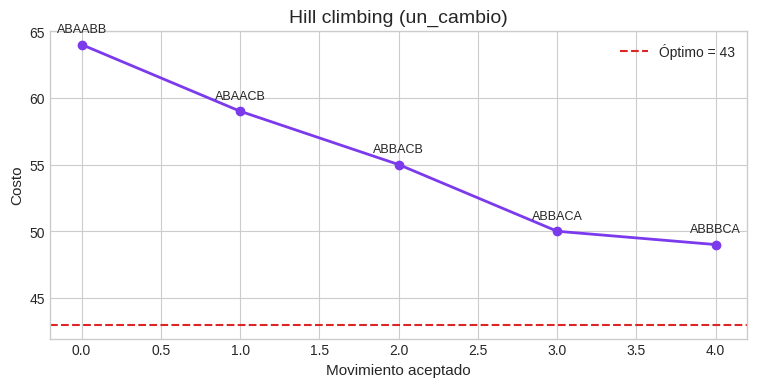

Hill climbing con un solo cambio: ABBBCA | costo = 49 min | FACTIBLE


,Pedido,Repartidor,Minutos
0,P1,A,7
1,P2,B,9
2,P3,B,9
3,P4,B,7
4,P5,C,8
5,P6,A,9


Evaluó 28 vecinos. Se atoró porque ninguno mejora el costo 49.


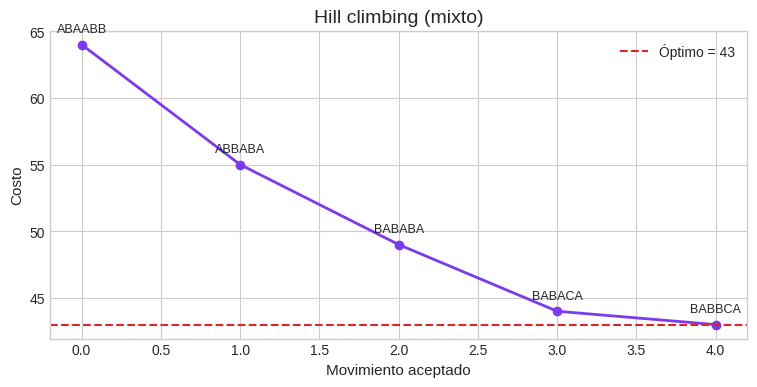

Hill climbing con intercambios permitidos: BABBCA | costo = 43 min | FACTIBLE


,Pedido,Repartidor,Minutos
0,P1,B,4
1,P2,A,6
2,P3,B,9
3,P4,B,7
4,P5,C,8
5,P6,A,9


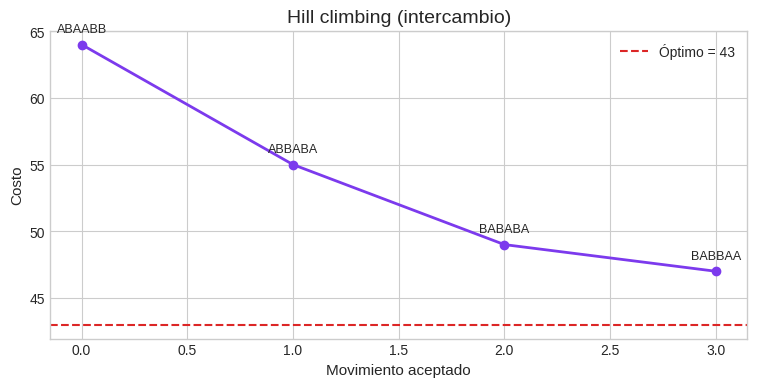

Hill climbing con intercambios permitidos: BABBAA | costo = 47 min | FACTIBLE


,Pedido,Repartidor,Minutos
0,P1,B,4
1,P2,A,6
2,P3,B,9
3,P4,B,7
4,P5,A,12
5,P6,A,9


In [29]:
#INICIO_LOCAL = tuple("ABAABB")
INICIO_LOCAL =  tuple("ABAABB")


def vecinos_un_cambio(solucion, capacidad=3):
    s = normalizar(solucion)
    vecinos = []
    for i in range(len(s)):
        for r in REPARTIDORES:
            if r == s[i]:
                continue
            nuevo = s[:i] + (r,) + s[i + 1:]
            if es_factible(nuevo, capacidad):
                vecinos.append(nuevo)
    return vecinos


def vecinos_intercambio(solucion, capacidad=3):
    s = normalizar(solucion)
    vecinos = []
    for i in range(len(s)):
        for j in range(i + 1, len(s)):
            if s[i] == s[j]:
                continue
            nuevo = list(s)
            nuevo[i], nuevo[j] = nuevo[j], nuevo[i]
            nuevo = tuple(nuevo)
            if es_factible(nuevo, capacidad) and nuevo not in vecinos:
                vecinos.append(nuevo)
    return vecinos


def obtener_vecinos(solucion, vecindario="un_cambio", capacidad=3):
    if vecindario == "un_cambio":
        return vecinos_un_cambio(solucion, capacidad)
    if vecindario == "intercambio":
        return vecinos_intercambio(solucion, capacidad)
    if vecindario == "mixto":
        return list(dict.fromkeys(
            vecinos_un_cambio(solucion, capacidad) + vecinos_intercambio(solucion, capacidad)
        ))
    raise ValueError("vecindario debe ser 'un_cambio', 'intercambio' o 'mixto'")


def hill_climbing(inicial=INICIO_LOCAL, vecindario="un_cambio", max_pasos=50, capacidad=3):
    actual = normalizar(inicial)
    if not es_factible(actual, capacidad):
        raise ValueError("La solución inicial debe ser factible.")

    historia = [{"paso": 0, "solucion": "".join(actual), "costo": costo(actual)}]
    evaluadas = 0


    for paso in range(1, max_pasos + 1):
        vecinos = obtener_vecinos(actual, vecindario, capacidad)
        evaluadas += len(vecinos)
        mejor_vecino = min(vecinos, key=costo)
        if costo(mejor_vecino) >= costo(actual):
            break
        actual = mejor_vecino
        historia.append({"paso": paso, "solucion": "".join(actual), "costo": costo(actual)})

    df = pd.DataFrame(historia)
    return {
        "metodo": f"Hill climbing ({vecindario})",
        "solucion": actual,
        "costo": costo(actual),
        "evaluadas": evaluadas,
        "historia": df,
        "traza_x": df["paso"].tolist(),
        "traza_mejor": df["costo"].tolist(),
        "garantiza": False,
        "parametros": {"inicial": "".join(normalizar(inicial)), "vecindario": vecindario},
    }


def graficar_trayectoria(resultado):
    h = resultado["historia"]
    plt.figure(figsize=(9, 4))
    plt.plot(h["paso"], h["costo"], marker="o", linewidth=2, color="#7C3AED")
    plt.axhline(OPTIMO, color=ROJO, linestyle="--", label=f"Óptimo = {OPTIMO}")
    for _, fila in h.iterrows():
        plt.annotate(fila["solucion"], (fila["paso"], fila["costo"]),
                     textcoords="offset points", xytext=(0, 9), ha="center", fontsize=9)
    plt.xlabel("Movimiento aceptado")
    plt.ylabel("Costo")
    plt.title(resultado["metodo"])
    plt.legend()
    plt.show()


R_HILL_1 = hill_climbing(vecindario="un_cambio")
R_HILL_SWAP = hill_climbing(vecindario="mixto")
# Jacobo Duez : Aquí implementé la evaluacion de hill_climbing() usando la variable vecindario como Intercambio
R_HILL_INTERCAMBIO  =  hill_climbing(vecindario="intercambio")

graficar_trayectoria(R_HILL_1)
mostrar_solucion(R_HILL_1["solucion"], "Hill climbing con un solo cambio")
print(f"Evaluó {R_HILL_1['evaluadas']} vecinos. Se atoró porque ninguno mejora el costo 49.")

graficar_trayectoria(R_HILL_SWAP)
mostrar_solucion(R_HILL_SWAP["solucion"], "Hill climbing con intercambios permitidos")

# Jacobo Duez : Aquí implementé la evaluacion de hill_climbing() usando la variable vecindario como Intercambio
graficar_trayectoria(R_HILL_INTERCAMBIO)
mostrar_solucion(R_HILL_INTERCAMBIO["solucion"], "Hill climbing con intercambios permitidos")


### LABORATORIO B — Animar la trayectoria

La siguiente función muestra cada solución aceptada. Cambia el vecindario y observa en qué momento aparece o desaparece la salida del óptimo local.


Paso 3 · Hill climbing (intercambio): BABBAA | costo = 47 min | FACTIBLE


,Pedido,Repartidor,Minutos
0,P1,B,4
1,P2,A,6
2,P3,B,9
3,P4,B,7
4,P5,A,12
5,P6,A,9


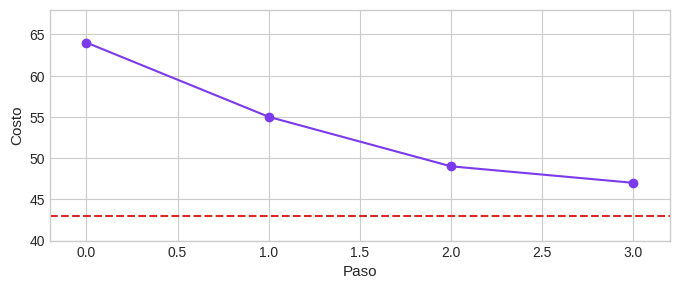

In [30]:
def animar_trayectoria(resultado, pausa=0.8):
    h = resultado["historia"]
    for _, fila in h.iterrows():
        clear_output(wait=True)
        mostrar_solucion(fila["solucion"], f"Paso {fila['paso']} · {resultado['metodo']}")
        vistos = h[h["paso"] <= fila["paso"]]
        plt.figure(figsize=(8, 3))
        plt.plot(vistos["paso"], vistos["costo"], marker="o", color="#7C3AED")
        plt.axhline(OPTIMO, color=ROJO, linestyle="--")
        plt.xlim(-0.2, max(1, h["paso"].max()) + 0.2)
        plt.ylim(40, max(h["costo"].max() + 4, 55))
        plt.xlabel("Paso")
        plt.ylabel("Costo")
        plt.show()
        time.sleep(pausa)


# Descomenta una línea para ver la animación:
animar_trayectoria(R_HILL_1, pausa=0.7)
animar_trayectoria(R_HILL_SWAP, pausa=0.7)
animar_trayectoria(R_HILL_INTERCAMBIO,pausa=0.7)


## 6. Recocido simulado: aceptar empeorar para poder escapar

Si el vecino cuesta menos, se acepta. Si cuesta más, todavía puede aceptarse con probabilidad

$$P(\text{aceptar})=e^{-\Delta/T}$$

donde $\Delta$ es cuánto empeora y $T$ es la temperatura.

- Temperatura alta: acepta exploración y movimientos malos con mayor frecuencia.
- Temperatura baja: se parece cada vez más a hill climbing.
- `alpha` cercano a 1: enfría lentamente.
- `alpha` pequeño: enfría rápidamente y puede congelarse antes de escapar.


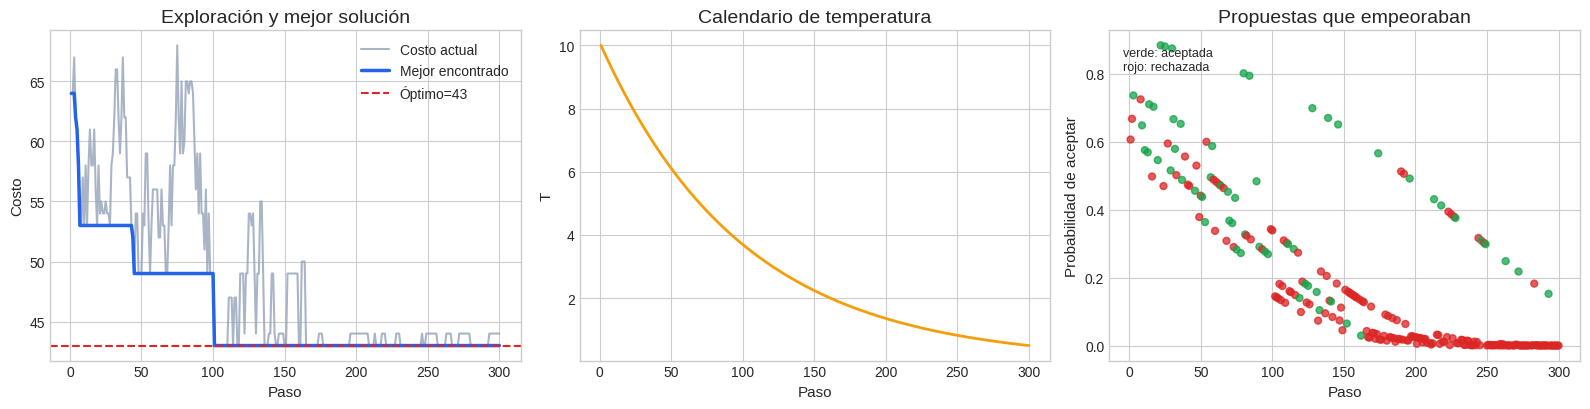

Mejor solución del recocido: BABBCA | costo = 43 min | FACTIBLE


,Pedido,Repartidor,Minutos
0,P1,B,4
1,P2,A,6
2,P3,B,9
3,P4,B,7
4,P5,C,8
5,P6,A,9


Aceptó 120 movimientos; 57 de ellos empeoraban temporalmente.


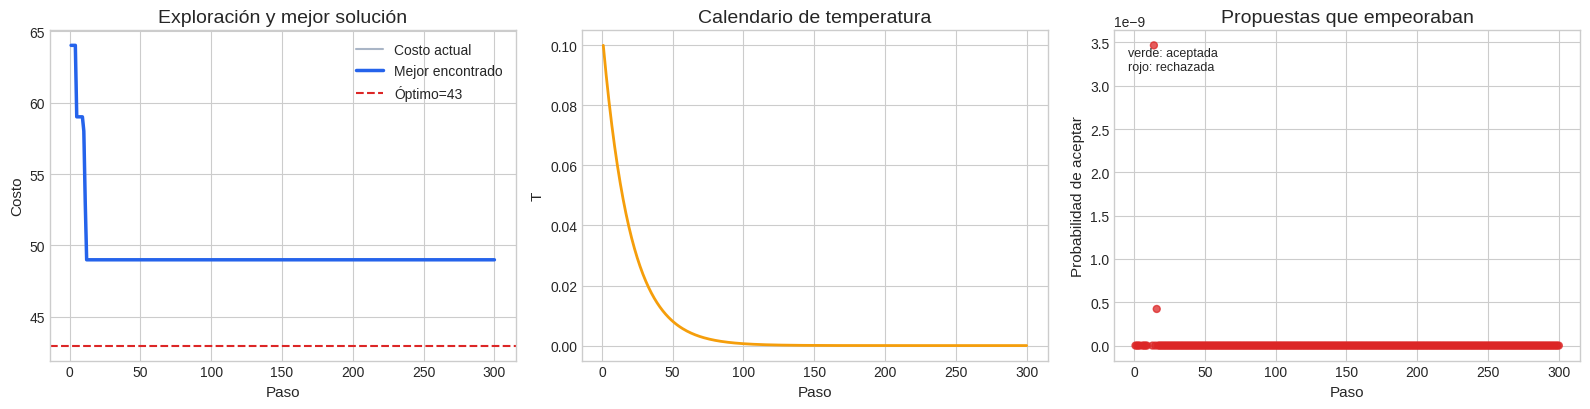

Mejor solución del recocido: ABBBCA | costo = 49 min | FACTIBLE


,Pedido,Repartidor,Minutos
0,P1,A,7
1,P2,B,9
2,P3,B,9
3,P4,B,7
4,P5,C,8
5,P6,A,9


Aceptó 4 movimientos ; 0 de ellos empeoraban temporalmente


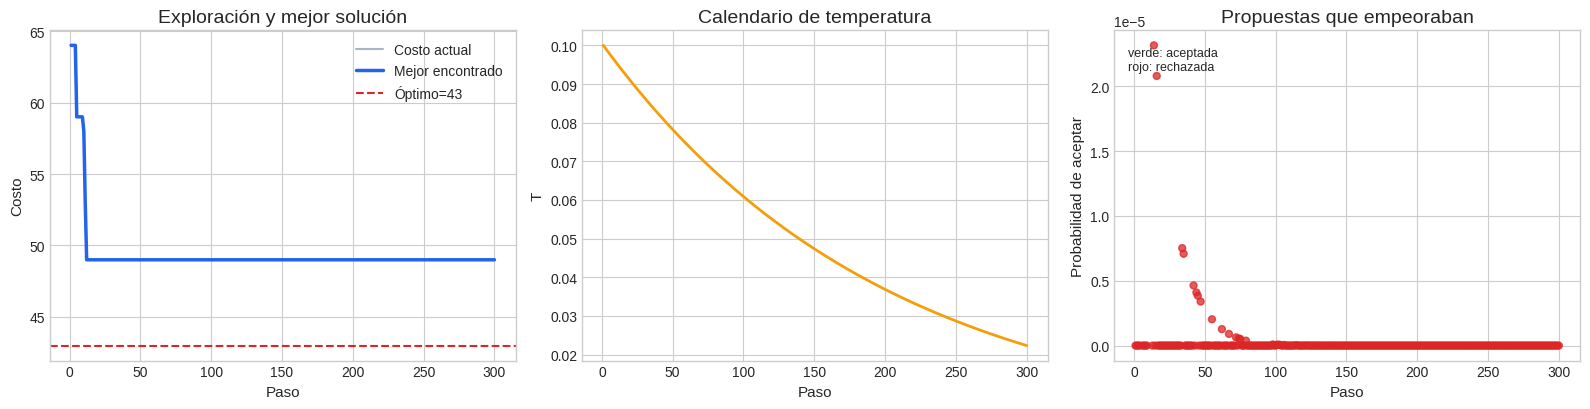

Mejor solución del recocido en frio y lento!: ABBBCA | costo = 49 min | FACTIBLE


,Pedido,Repartidor,Minutos
0,P1,A,7
1,P2,B,9
2,P3,B,9
3,P4,B,7
4,P5,C,8
5,P6,A,9


Aceptó 4 movimientos ; 0 de ellos empeoraban temporalmente


In [46]:
def recocido_simulado(
    inicial=INICIO_LOCAL,
    temperatura_inicial=10.0,
    alpha=0.99,
    pasos=300,
    semilla=0,
    vecindario="un_cambio",
    capacidad=3,
    registrar_historia=True,
):
    if temperatura_inicial <= 0:
        raise ValueError("La temperatura inicial debe ser positiva.")
    if not (0 < alpha <= 1):
        raise ValueError("alpha debe estar entre 0 y 1.")

    rng = random.Random(semilla)
    actual = normalizar(inicial)
    if not es_factible(actual, capacidad):
        raise ValueError("La solución inicial debe ser factible.")
    mejor = actual
    T = float(temperatura_inicial)
    aceptados = 0
    empeoran_aceptados = 0
    filas = []

    for k in range(1, pasos + 1):
        vecinos = obtener_vecinos(actual, vecindario, capacidad)
        candidato = rng.choice(vecinos)
        delta = costo(candidato) - costo(actual)
        probabilidad = 1.0 if delta <= 0 else math.exp(-delta / max(T, 1e-12))
        aceptado = delta <= 0 or rng.random() < probabilidad

        if aceptado:
            aceptados += 1
            if delta > 0:
                empeoran_aceptados += 1
            actual = candidato
            if costo(actual) < costo(mejor):
                mejor = actual

        if registrar_historia:
            filas.append({
                "paso": k,
                "temperatura": T,
                "costo_actual": costo(actual),
                "mejor_costo": costo(mejor),
                "delta_propuesto": delta,
                "prob_aceptar": probabilidad,
                "aceptado": aceptado,
                "acepto_empeorar": bool(aceptado and delta > 0),
                "solucion_actual": "".join(actual),
                "mejor_solucion": "".join(mejor),
            })
        T *= alpha

    historia = pd.DataFrame(filas)
    return {
        "metodo": "Recocido simulado",
        "solucion": mejor,
        "costo": costo(mejor),
        "evaluadas": pasos,
        "historia": historia,
        "aceptados": aceptados,
        "empeoran_aceptados": empeoran_aceptados,
        "garantiza": False,
        "parametros": {
            "T0": temperatura_inicial, "alpha": alpha, "pasos": pasos,
            "semilla": semilla, "vecindario": vecindario,
        },
    }


def graficar_recocido(resultado):
    h = resultado["historia"]
    fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))

    ax[0].plot(h["paso"], h["costo_actual"], color="#94A3B8", alpha=0.8, label="Costo actual")
    ax[0].plot(h["paso"], h["mejor_costo"], color="#2563EB", linewidth=2.5, label="Mejor encontrado")
    ax[0].axhline(OPTIMO, color=ROJO, linestyle="--", label=f"Óptimo={OPTIMO}")
    ax[0].set_title("Exploración y mejor solución")
    ax[0].set_xlabel("Paso")
    ax[0].set_ylabel("Costo")
    ax[0].legend()

    ax[1].plot(h["paso"], h["temperatura"], color="#F59E0B", linewidth=2)
    ax[1].set_title("Calendario de temperatura")
    ax[1].set_xlabel("Paso")
    ax[1].set_ylabel("T")

    empeora = h[h["delta_propuesto"] > 0]
    colores = np.where(empeora["acepto_empeorar"], VERDE, ROJO)
    ax[2].scatter(empeora["paso"], empeora["prob_aceptar"], c=colores, alpha=0.75, s=25)
    ax[2].set_title("Propuestas que empeoraban")
    ax[2].set_xlabel("Paso")
    ax[2].set_ylabel("Probabilidad de aceptar")
    ax[2].text(0.03, 0.95, "verde: aceptada\nrojo: rechazada", transform=ax[2].transAxes,
               va="top", fontsize=9)

    plt.tight_layout()
    plt.show()


R_SA = recocido_simulado(temperatura_inicial=10, alpha=0.99, pasos=300, semilla=30)
graficar_recocido(R_SA)
mostrar_solucion(R_SA["solucion"], "Mejor solución del recocido")
print(f"Aceptó {R_SA['aceptados']} movimientos; {R_SA['empeoran_aceptados']} de ellos empeoraban temporalmente.")

#reto 2
R_SA_Temp01 =  recocido_simulado(temperatura_inicial=0.1,alpha=0.95,pasos=300,semilla=30)
graficar_recocido(R_SA_Temp01)
mostrar_solucion(R_SA_Temp01["solucion"], "Mejor solución del recocido")
print(f"Aceptó {R_SA_Temp01['aceptados']} movimientos ; {R_SA_Temp01['empeoran_aceptados']} de ellos empeoraban temporalmente")

#reto 3
R_SA_Temp03 =  recocido_simulado(temperatura_inicial=0.1,alpha=0.995,pasos=300,semilla=30)
graficar_recocido(R_SA_Temp03)
mostrar_solucion(R_SA_Temp03["solucion"], "Mejor solución del recocido en frio y lento!")
print(f"Aceptó {R_SA_Temp03['aceptados']} movimientos ; {R_SA_Temp03['empeoran_aceptados']} de ellos empeoraban temporalmente")


### LABORATORIO C — El efecto matemático de la temperatura

Mueve $\Delta$ para representar un vecino un poco o muy malo. Observa qué temperatura se necesita para conservar una probabilidad apreciable de aceptarlo.


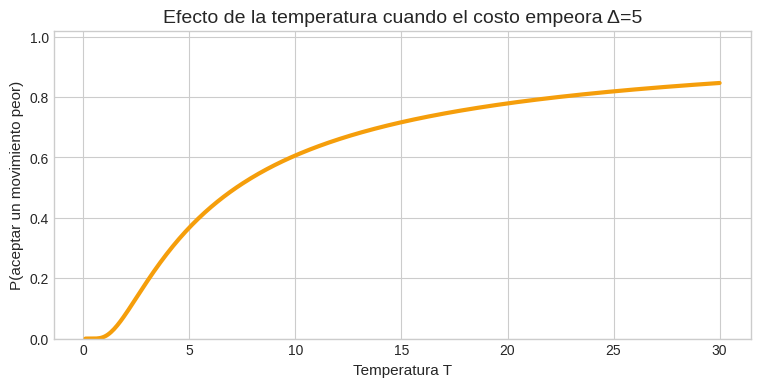

In [38]:
def visualizar_probabilidad(delta=5):
    temperaturas = np.linspace(0.1, 30, 400)
    probabilidades = np.exp(-delta / temperaturas)
    plt.figure(figsize=(9, 4))
    plt.plot(temperaturas, probabilidades, color="#F59E0B", linewidth=3)
    plt.ylim(0, 1.02)
    plt.xlabel("Temperatura T")
    plt.ylabel("P(aceptar un movimiento peor)")
    plt.title(f"Efecto de la temperatura cuando el costo empeora Δ={delta}")
    plt.show()


visualizar_probabilidad(delta=5)


### LABORATORIO D — Controles interactivos para el recocido

Mueve los controles y busca configuraciones que:

1. se congelen en 49;
2. alcancen 43;
3. exploren demasiado y nunca se estabilicen;
4. obtengan resultados distintos al cambiar sólo la semilla.


In [37]:
try:
    from google.colab import output
    output.enable_custom_widget_manager()
except Exception:
    pass

from ipywidgets import interact, FloatSlider, IntSlider, Dropdown


@interact(
    temperatura_inicial=FloatSlider(value=10, min=0.1, max=30, step=0.5, description="T inicial"),
    alpha=FloatSlider(value=0.99, min=0.90, max=0.999, step=0.001, readout_format=".3f"),
    pasos=IntSlider(value=300, min=50, max=1000, step=50),
    semilla=IntSlider(value=0, min=0, max=30, step=1),
    vecindario=Dropdown(options=["un_cambio", "intercambio", "mixto"], value="un_cambio"),
)
def laboratorio_recocido(temperatura_inicial, alpha, pasos, semilla, vecindario):
    r = recocido_simulado(
        temperatura_inicial=temperatura_inicial,
        alpha=alpha,
        pasos=pasos,
        semilla=semilla,
        vecindario=vecindario,
    )
    graficar_recocido(r)
    print(
        f"Mejor costo: {r['costo']} | Solución: {''.join(r['solucion'])} | "
        f"Aceptó {r['empeoran_aceptados']} movimientos que empeoraban"
    )


interactive(children=(FloatSlider(value=10.0, description='T inicial', max=30.0, min=0.1, step=0.5), FloatSlid…

## 7. ¿En qué proporción funciona? Mapa de tasa de éxito

Una sola corrida no demuestra que el recocido “funciona”. Como es aleatorio, repetimos cada configuración con varias semillas y calculamos:

$$\text{tasa de éxito}=\frac{\text{corridas que alcanzaron el óptimo}}{\text{corridas totales}}$$

Esta gráfica permite ver el efecto conjunto de la temperatura inicial y la velocidad de enfriamiento.


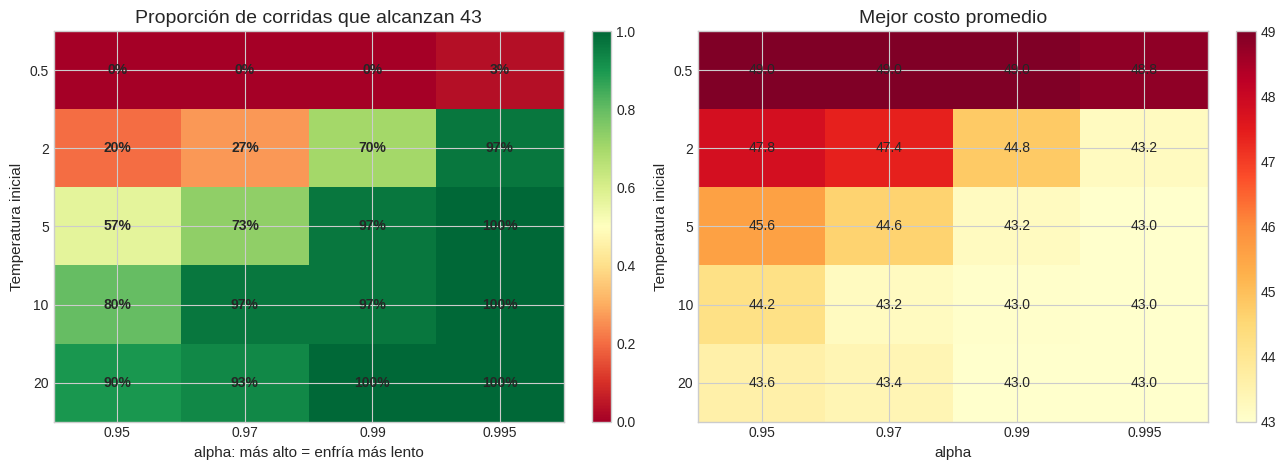

In [48]:
def mapa_tasa_exito(
    temperaturas=(0.5, 2, 5, 10, 20),
    alphas=(0.95, 0.97, 0.99, 0.995),
    repeticiones=30,
    pasos=300,
    vecindario="un_cambio",
):
    tasas = np.zeros((len(temperaturas), len(alphas)))
    costos_medios = np.zeros_like(tasas)

    for i, T0 in enumerate(temperaturas):
        for j, alpha in enumerate(alphas):
            costos_finales = []
            for semilla in range(repeticiones):
                r = recocido_simulado(
                    temperatura_inicial=T0,
                    alpha=alpha,
                    pasos=pasos,
                    semilla=semilla,
                    vecindario=vecindario,
                    registrar_historia=False,
                )
                costos_finales.append(r["costo"])
            tasas[i, j] = np.mean(np.array(costos_finales) == OPTIMO)
            costos_medios[i, j] = np.mean(costos_finales)

    fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
    im1 = ax[0].imshow(tasas, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
    ax[0].set_title(f"Proporción de corridas que alcanzan {OPTIMO}")
    ax[0].set_xticks(range(len(alphas)), [str(a) for a in alphas])
    ax[0].set_yticks(range(len(temperaturas)), [str(t) for t in temperaturas])
    ax[0].set_xlabel("alpha: más alto = enfría más lento")
    ax[0].set_ylabel("Temperatura inicial")
    for i in range(len(temperaturas)):
        for j in range(len(alphas)):
            ax[0].text(j, i, f"{tasas[i,j]:.0%}", ha="center", va="center", fontweight="bold")
    fig.colorbar(im1, ax=ax[0], fraction=0.046)

    im2 = ax[1].imshow(costos_medios, cmap="YlOrRd", aspect="auto")
    ax[1].set_title("Mejor costo promedio")
    ax[1].set_xticks(range(len(alphas)), [str(a) for a in alphas])
    ax[1].set_yticks(range(len(temperaturas)), [str(t) for t in temperaturas])
    ax[1].set_xlabel("alpha")
    ax[1].set_ylabel("Temperatura inicial")
    for i in range(len(temperaturas)):
        for j in range(len(alphas)):
            ax[1].text(j, i, f"{costos_medios[i,j]:.1f}", ha="center", va="center")
    fig.colorbar(im2, ax=ax[1], fraction=0.046)

    plt.tight_layout()
    plt.show()
    return pd.DataFrame(tasas, index=temperaturas, columns=alphas)


TASAS_EXITO = mapa_tasa_exito(repeticiones=30, pasos=300)


## 8. Comparación final sobre el mismo problema

La primera gráfica compara trabajo. La segunda compara calidad. Es importante observar que **trabajar menos no implica encontrar una mejor solución**.


,Método,Evaluaciones,Costo final,Encontró 43,Garantiza el óptimo
0,Búsqueda exhaustiva,729,43,True,True
1,Backtracking,264,43,True,True
2,Backtracking + propagación,75,43,True,True
3,Hill climbing (un_cambio),28,49,False,False
4,Hill climbing (mixto),51,43,True,False
5,Recocido simulado,300,43,True,False


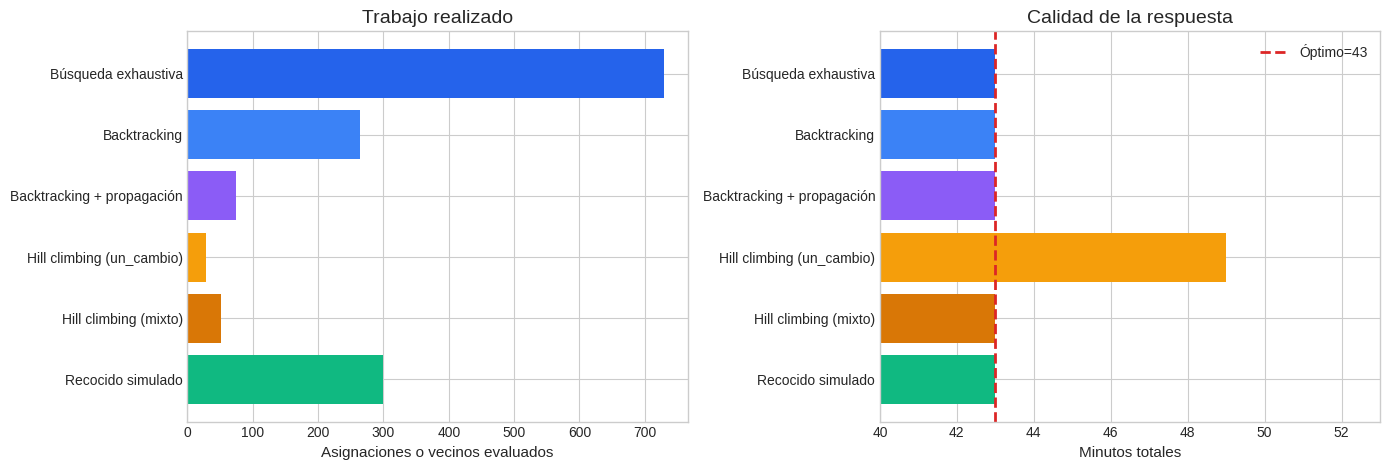

In [ ]:
def comparar_todos():
    resultados = [
        R_EXH,
        R_BT,
        R_PROP,
        R_HILL_1,
        R_HILL_SWAP,
        R_SA,
    ]
    filas = []
    for r in resultados:
        filas.append({
            "Método": r["metodo"],
            "Evaluaciones": r["evaluadas"],
            "Costo final": r["costo"],
            "Encontró 43": r["costo"] == OPTIMO,
            "Garantiza el óptimo": r["garantiza"],
        })
    df = pd.DataFrame(filas)
    display(df)

    fig, ax = plt.subplots(1, 2, figsize=(14, 4.8))
    colores = ["#2563EB", "#3B82F6", "#8B5CF6", "#F59E0B", "#D97706", "#10B981"]
    ax[0].barh(df["Método"], df["Evaluaciones"], color=colores)
    ax[0].set_title("Trabajo realizado")
    ax[0].set_xlabel("Asignaciones o vecinos evaluados")
    ax[0].invert_yaxis()

    ax[1].barh(df["Método"], df["Costo final"], color=colores)
    ax[1].axvline(OPTIMO, color=ROJO, linestyle="--", linewidth=2, label=f"Óptimo={OPTIMO}")
    ax[1].set_title("Calidad de la respuesta")
    ax[1].set_xlabel("Minutos totales")
    ax[1].set_xlim(40, max(df["Costo final"]) + 4)
    ax[1].invert_yaxis()
    ax[1].legend()

    plt.tight_layout()
    plt.show()
    return df


COMPARACION = comparar_todos()


## 9. Retos para experimentar

No contestes únicamente con “subió” o “bajó”. En cada experimento explica **qué cambió en el comportamiento del algoritmo y por qué**.

### Reto 1 — Vecindario

Compara hill climbing con `un_cambio`, `intercambio` y `mixto`.

- ¿Cuál se atora? Los tres algoritmos arrojan resultados factibles.
- ¿Cuál ve la salida de 49 a 43? Hill Climbing Mixto, mezclando el intercambio de dos pedidos + la reasignación reduce el tiempo de repartición de 49 a 43.
- ¿Un vecindario más grande siempre implica menos trabajo?Es posible, pero no esta garantizado. El resultado del algoritmo también depende de las restricciones y de las posibles combinaciones. Al intercambiar o reasignar puede haber más combinaciones pero no necesariamente implica menos trabajo.

### Reto 2 — Temperatura demasiado baja

Ejecuta recocido con `temperatura_inicial=0.1` y `alpha=0.95`.

- ¿En qué se parece ahora a hill climbing? Ambos, Hill_Climbing y recocido simulado muestran valores óptimos de 43. Ambos logran los resultados óptimos.
- ¿Cuántos movimientos que empeoraban aceptó? Muy pocos, la probabilidad de aceptación de movimientos que empeoran es 0 o muy cercana a 0

### Reto 3 — Enfriamiento lento

Compara `alpha=0.95` y `alpha=0.995`, conservando todo lo demás.

- ¿Cuál explora durante más tiempo? El recocido lento con un parámetro Alpha de .95 tiene un factor de reducción de temperatura mayor, lo cual significa que explora por menos tiempo. Alpha de 0.995, explora más tiempo.
- ¿Cuál tiene mayor tasa de éxito en 30 semillas? Con 30 semillas y Alpha de .95 parece haber mayor tasa de éxito pues hay pocas propuestas cuya probabilidad de ser seleccionada es menor versus mucho más propuestas en el recocido simulado con 30 semillas y Alpha de .995. En resumen

### Reto 4 — Presupuesto de cálculo

Compara 50, 100, 300 y 1000 pasos.

- ¿En qué punto dejan de aparecer mejoras importantes? A partir del paso 50 ya no se encuentran mejores soluciones.
- ¿Qué estarías dispuesto a sacrificar en un problema real: tiempo o certeza? En la vida real, trataría de resolver el problema lo más rápido posible, tener una mejora rápida y posteriormente optimizar la mejora y entenderla mejor para aumentar mi certeza. Esto suponiendo que se trata de optimizar al minimizar un problema de costos.

### Reto 5 — Formula una conclusión profesional

Completa:

> Para este problema elegiría __la búsqueda exhaustiva_______ porque _____la cantidad de asignaciones no sería tan grande_____. Sin embargo, si el problema creciera a diez mil variables, cambiaría a recocido_simulado ___ _______ porque al tener parámetros como la temperatura y el delta en la temperatura podría experimentar rápidamente con el algoritmo y encontrar una solución factible y buena muy rapidamente__________.


## Cierre

- La exhaustiva mira todo y garantiza.
- Backtracking obtiene la misma garantía podando ramas.
- La propagación y las cotas permiten podar antes.
- Hill climbing trabaja poco, pero depende completamente del vecindario.
- El recocido puede escapar aceptando pérdidas temporales, pero su resultado depende de parámetros y aleatoriedad.

> **Optimizar no es hacer que un número baje: es decidir qué solución buscamos, qué reglas deben respetarse y cuánto trabajo estamos dispuestos a invertir para encontrarla.**
